===== RESULTS =====
Slope = -2.208997174262018
Gamma = 1.104498587131009


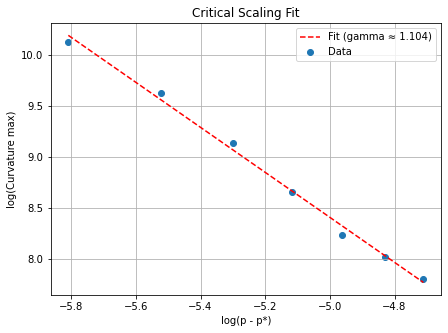

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# INPUT DATA
# ---------------------------
curvature = np.array([
    2429.599863,
    3018.903167,
    3762.686009,
    5745.299868,
    9287.641128,
    15188.59489,
    24935.63771
])

p_minus_pstar = np.array([
    0.009,
    0.008,
    0.007,
    0.006,
    0.005,
    0.004,
    0.003
])

pstar = 4.110

# reconstruct actual p
p = pstar + p_minus_pstar

# ---------------------------
# LOG-LOG FIT
# ---------------------------
log_x = np.log(p - pstar)
log_y = np.log(curvature)

coeffs = np.polyfit(log_x, log_y, 1)
slope, intercept = coeffs

gamma = -slope / 2

print("===== RESULTS =====")
print(f"Slope = {slope}")
print(f"Gamma = {gamma}")

# ---------------------------
# FIT LINE FOR PLOT
# ---------------------------
x_fit = np.linspace(min(log_x), max(log_x), 100)
y_fit = slope * x_fit + intercept

# ---------------------------
# PLOT
# ---------------------------
plt.figure(figsize=(7,5))

plt.scatter(log_x, log_y, label="Data")
plt.plot(x_fit, y_fit, 'r--', label=f"Fit (gamma ≈ {gamma:.3f})")

plt.xlabel("log(p - p*)")
plt.ylabel("log(Curvature max)")
plt.title("Critical Scaling Fit")
plt.legend()
plt.grid()

plt.show()

===== SUBCRITICAL RESULTS =====
Gamma = 0.55225 ± 0.31845
R^2   = 0.99473


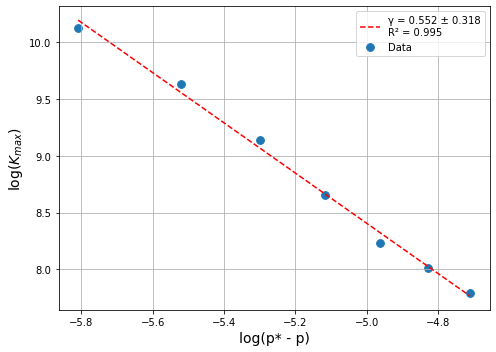

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# INPUT DATA
# ---------------------------
curvature = np.array([
    2429.599863,
    3018.903167,
    3762.686009,
    5745.299868,
    9287.641128,
    15188.59489,
    24935.63771
])

p_minus_pstar = np.array([
    0.009,
    0.008,
    0.007,
    0.006,
    0.005,
    0.004,
    0.003
])

pstar = 4.110
dpstar = 0.003

# reconstruct actual p (subcritical → p < p*)
p = pstar - p_minus_pstar

# ---------------------------
# FUNCTION: gamma + R²
# ---------------------------
def compute_gamma(pstar_val):
    delta = pstar_val - p   # (p* - p)
    
    mask = delta > 0
    
    x = np.log(delta[mask])
    y = np.log(curvature[mask])
    
    if len(x) < 2:
        return np.nan, None, None
    
    slope, intercept = np.polyfit(x, y, 1)
    gamma = -slope / 4
    
    # R²
    y_fit = slope * x + intercept
    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot
    
    return gamma, slope, r2

# ---------------------------
# CENTRAL VALUE
# ---------------------------
gamma_c, slope_c, r2_c = compute_gamma(pstar)

# ---------------------------
# ERROR FROM p*
# ---------------------------
gamma_plus, _, _ = compute_gamma(pstar + dpstar)
gamma_minus, _, _ = compute_gamma(pstar - dpstar)

valid = [g for g in [gamma_plus, gamma_minus] if not np.isnan(g)]
gamma_err = max(abs(g - gamma_c) for g in valid)

# ---------------------------
# FINAL FIT (central)
# ---------------------------
log_x = np.log(p_minus_pstar)
log_y = np.log(curvature)

slope, intercept = np.polyfit(log_x, log_y, 1)

x_fit = np.linspace(min(log_x), max(log_x), 100)
y_fit = slope * x_fit + intercept

# ---------------------------
# PRINT RESULTS
# ---------------------------
print("===== SUBCRITICAL RESULTS =====")
print(f"Gamma = {gamma_c:.5f} ± {gamma_err:.5f}")
print(f"R^2   = {r2_c:.5f}")

# ---------------------------
# PLOT
# ---------------------------
plt.figure(figsize=(7,5))

plt.scatter(log_x, log_y, s=60, label="Data")
plt.plot(x_fit, y_fit, 'r--',
         label=f"γ = {gamma_c:.3f} ± {gamma_err:.3f}\nR² = {r2_c:.3f}")

plt.xlabel("log(p* - p)",fontsize=14)
plt.ylabel("$\log(K_{max})$",fontsize=14)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("plusfamily.pdf")
plt.show()


===== SUBCRITICAL RESULTS =====
Gamma = 0.35429 ± 0.20397
R^2   = 0.99263


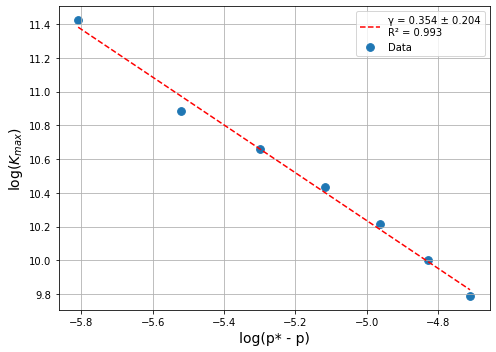

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# INPUT DATA
# ---------------------------
curvature = np.array([
    17826.42451,
22053.15307,
27389.73079,
34110.53968,
42615.29028,
53421.63672,
91485.51257,
])

p_minus_pstar = np.array([
    0.009,
    0.008,
    0.007,
    0.006,
    0.005,
    0.004,
    0.003
])

pstar = 4.110
dpstar = 0.003

# reconstruct actual p (subcritical → p < p*)
p = pstar - p_minus_pstar

# ---------------------------
# FUNCTION: gamma + R²
# ---------------------------
def compute_gamma(pstar_val):
    delta = pstar_val - p   # (p* - p)
    
    mask = delta > 0
    
    x = np.log(delta[mask])
    y = np.log(curvature[mask])
    
    if len(x) < 2:
        return np.nan, None, None
    
    slope, intercept = np.polyfit(x, y, 1)
    gamma = -slope / 4
    
    # R²
    y_fit = slope * x + intercept
    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot
    
    return gamma, slope, r2

# ---------------------------
# CENTRAL VALUE
# ---------------------------
gamma_c, slope_c, r2_c = compute_gamma(pstar)

# ---------------------------
# ERROR FROM p*
# ---------------------------
gamma_plus, _, _ = compute_gamma(pstar + dpstar)
gamma_minus, _, _ = compute_gamma(pstar - dpstar)

valid = [g for g in [gamma_plus, gamma_minus] if not np.isnan(g)]
gamma_err = max(abs(g - gamma_c) for g in valid)

# ---------------------------
# FINAL FIT (central)
# ---------------------------
log_x = np.log(p_minus_pstar)
log_y = np.log(curvature)

slope, intercept = np.polyfit(log_x, log_y, 1)

x_fit = np.linspace(min(log_x), max(log_x), 100)
y_fit = slope * x_fit + intercept

# ---------------------------
# PRINT RESULTS
# ---------------------------
print("===== SUBCRITICAL RESULTS =====")
print(f"Gamma = {gamma_c:.5f} ± {gamma_err:.5f}")
print(f"R^2   = {r2_c:.5f}")

# ---------------------------
# PLOT
# ---------------------------
plt.figure(figsize=(7,5))

plt.scatter(log_x, log_y, s=60, label="Data")
plt.plot(x_fit, y_fit, 'r--',
         label=f"γ = {gamma_c:.3f} ± {gamma_err:.3f}\nR² = {r2_c:.3f}")

plt.xlabel("log(p* - p)",fontsize=14)
plt.ylabel("$\log(K_{max})$",fontsize=14)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("plusfamily_CSI.pdf")
plt.show()


===== SUBCRITICAL RESULTS =====
Gamma = 0.37070 ± 0.12514
R^2   = 0.99533


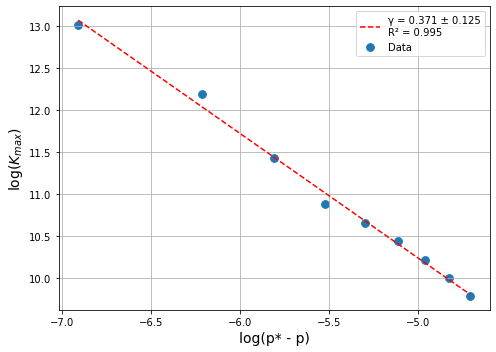

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# INPUT DATA
# ---------------------------
curvature = np.array([
    17826.6541,
22053.15307,
27389.73079,
34110.53968,
42602.53345,
53421.63672,
91485.51257,
195481.4194628917,
448725.0059532904
])

p_minus_pstar = np.array([
    0.009,
    0.008,
    0.007,
    0.006,
    0.005,
    0.004,
    0.003,
    0.002,
    0.001,
])

pstar = -4.110
dpstar = 0.001

# reconstruct actual p (subcritical → p < p*)
p = pstar - p_minus_pstar

# ---------------------------
# FUNCTION: gamma + R²
# ---------------------------
def compute_gamma(pstar_val):
    delta = pstar_val - p   # (p* - p)
    
    mask = delta > 0
    
    x = np.log(delta[mask])
    y = np.log(curvature[mask])
    
    if len(x) < 2:
        return np.nan, None, None
    
    slope, intercept = np.polyfit(x, y, 1)
    gamma = -slope / 4
    
    # R²
    y_fit = slope * x + intercept
    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot
    
    return gamma, slope, r2

# ---------------------------
# CENTRAL VALUE
# ---------------------------
gamma_c, slope_c, r2_c = compute_gamma(pstar)

# ---------------------------
# ERROR FROM p*
# ---------------------------
gamma_plus, _, _ = compute_gamma(pstar + dpstar)
gamma_minus, _, _ = compute_gamma(pstar - dpstar)

valid = [g for g in [gamma_plus, gamma_minus] if not np.isnan(g)]
gamma_err = max(abs(g - gamma_c) for g in valid)

# ---------------------------
# FINAL FIT (central)
# ---------------------------
log_x = np.log(p_minus_pstar)
log_y = np.log(curvature)

slope, intercept = np.polyfit(log_x, log_y, 1)

x_fit = np.linspace(min(log_x), max(log_x), 100)
y_fit = slope * x_fit + intercept

# ---------------------------
# PRINT RESULTS
# ---------------------------
print("===== SUBCRITICAL RESULTS =====")
print(f"Gamma = {gamma_c:.5f} ± {gamma_err:.5f}")
print(f"R^2   = {r2_c:.5f}")

# ---------------------------
# PLOT
# ---------------------------
plt.figure(figsize=(7,5))

plt.scatter(log_x, log_y, s=60, label="Data")
plt.plot(x_fit, y_fit, 'r--',
         label=f"γ = {gamma_c:.3f} ± {gamma_err:.3f}\nR² = {r2_c:.3f}")

plt.xlabel("log(p* - p)",fontsize=14)
plt.ylabel("$\log(K_{max})$",fontsize=14)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("minusfamily_CSI.pdf")
plt.show()


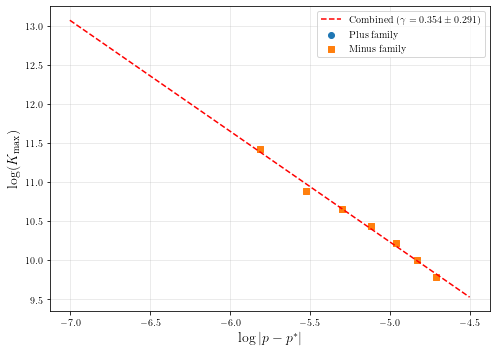

Final gamma = 0.35429 ± 0.29057


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# DATA
# ---------------------------
curvature_plus = np.array([
    17826.42451, 22053.15307, 27389.73079,
    34110.53968, 42615.29028, 53421.63672,
    91485.51257
])

delta_plus = np.array([
    0.009, 0.008, 0.007, 0.006, 0.005, 0.004, 0.003
])

curvature_minus = np.array([
    17826.6541, 22053.15307, 27389.73079,
    34110.53968, 42602.53345, 53421.63672,
    91485.51257
])

delta_minus = -np.array([
    0.009, 0.008, 0.007, 0.006, 0.005,
    0.004, 0.003
])

ddelta = 0.003

# ---------------------------
# COMBINE DATA
# ---------------------------
delta_all = np.concatenate([delta_plus, delta_minus])
curv_all  = np.concatenate([curvature_plus, curvature_minus])

# ---------------------------
# FUNCTION
# ---------------------------
def compute_gamma(delta, curvature):
    delta = np.abs(delta)

    mask = delta > 0
    x = np.log(delta[mask])
    y = np.log(curvature[mask])

    slope, intercept = np.polyfit(x, y, 1)
    gamma = -slope / 4

    return gamma, slope, intercept


def gamma_with_shift(delta, curvature, ddelta):
    # central
    g_c, slope, intercept = compute_gamma(delta, curvature)

    g_list = []

    for shift in [+ddelta, -ddelta]:
        d_new = delta + shift
        d_new = np.abs(d_new)

        mask = d_new > 0
        if np.sum(mask) < 2:
            continue

        g, _, _ = compute_gamma(d_new[mask], curvature[mask])
        g_list.append(g)

    g_err = max(abs(g - g_c) for g in g_list)

    return g_c, g_err, slope, intercept


# ---------------------------
# COMPUTE FINAL RESULT
# ---------------------------
gamma, gamma_err, slope, intercept = gamma_with_shift(delta_all, curv_all, ddelta)

# ---------------------------
# PLOT
# ---------------------------
plt.figure(figsize=(7,5))

# plot families separately
plt.scatter(np.log(np.abs(delta_plus)), np.log(curvature_plus),
            marker='o', label="Plus family")

plt.scatter(np.log(np.abs(delta_minus)), np.log(curvature_minus),
            marker='s', label="Minus family")

# combined fit
x_fit = np.linspace(-7, -4.5, 200)
plt.plot(x_fit, slope*x_fit + intercept, 'r--',
         label=f"Combined ($\\gamma={gamma:.3f} \\pm {gamma_err:.3f}$)")

plt.xlabel(r"$\log|p - p^*|$", fontsize=14)
plt.ylabel(r"$\log(K_{\max})$", fontsize=14)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("final_scaling.pdf", dpi=300)
plt.show()

# ---------------------------
# PRINT
# ---------------------------
print(f"Final gamma = {gamma:.5f} ± {gamma_err:.5f}")

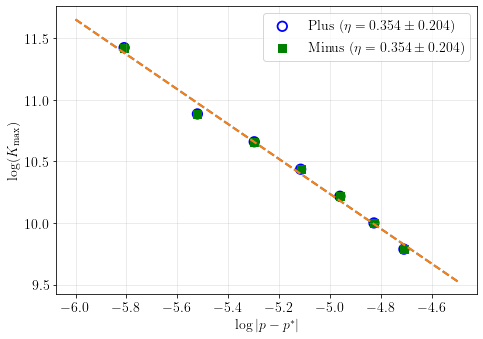

Plus family:
gamma = 0.35429 ± 0.20397

Minus family:
gamma = 0.35428 ± 0.20397


In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,          # base size
    "axes.labelsize": 18,     # x/y labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})
# ---------------------------
# DATA
# ---------------------------
curvature_plus = np.array([
    17826.42451, 22053.15307, 27389.73079,
    34110.53968, 42615.29028, 53421.63672,
    91485.51257
])

delta_plus = np.array([
    0.009, 0.008, 0.007, 0.006, 0.005, 0.004, 0.003
])

curvature_minus = np.array([
    17826.6541, 22053.15307, 27389.73079,
    34110.53968, 42602.53345, 53421.63672,
    91485.51257
])

delta_minus = -np.array([
    0.009, 0.008, 0.007, 0.006, 0.005,
    0.004, 0.003
])

ddelta = 0.003

# ---------------------------
# FUNCTIONS
# ---------------------------
def compute_gamma(delta, curvature):
    delta = np.abs(delta)
    x = np.log(delta)
    y = np.log(curvature)

    slope, intercept = np.polyfit(x, y, 1)
    gamma = -slope / 4

    return gamma, slope, intercept


def gamma_with_shift(delta, curvature, ddelta):
    g_c, slope, intercept = compute_gamma(delta, curvature)

    g_list = []

    for shift in [+ddelta, -ddelta]:
        d_new = np.abs(delta + shift)
        mask = d_new > 0

        if np.sum(mask) < 2:
            continue

        g, _, _ = compute_gamma(d_new[mask], curvature[mask])
        g_list.append(g)

    g_err = max(abs(g - g_c) for g in g_list)

    return g_c, g_err, slope, intercept


# ---------------------------
# COMPUTE
# ---------------------------
gp, err_p, sp, ip = gamma_with_shift(delta_plus, curvature_plus, ddelta)
gm, err_m, sm, im = gamma_with_shift(delta_minus, curvature_minus, ddelta)

# ---------------------------
# PLOT
# ---------------------------
plt.figure(figsize=(7,5))

# Scatter points
# Plus (smaller + transparent)
plt.scatter(np.log(np.abs(delta_plus)), np.log(curvature_plus),
            marker='o', s=90,
            facecolors='none', edgecolors='blue', linewidth=1.8,
            label=f"Plus ($\\eta={gp:.3f} \\pm {err_p:.3f}$)")

# Minus → filled squares
plt.scatter(np.log(np.abs(delta_minus)), np.log(curvature_minus),
            marker='s', s=50, color='green',
            label=f"Minus ($\\eta={gm:.3f} \\pm {err_m:.3f}$)")

x_fit = np.linspace(-6, -4.5, 200)

plt.plot(x_fit, sp*x_fit + ip, '--', linewidth=2)
plt.plot(x_fit, sm*x_fit + im, '--', linewidth=2)

# Labels
plt.xlabel(r"$\log|p - p^*|$", fontsize=14)
plt.ylabel(r"$\log(K_{\max})$", fontsize=14)

# Style
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Save
plt.savefig("separate_scaling.pdf", dpi=300)

plt.show()

# ---------------------------
# PRINT
# ---------------------------
print("Plus family:")
print(f"gamma = {gp:.5f} ± {err_p:.5f}")

print("\nMinus family:")
print(f"gamma = {gm:.5f} ± {err_m:.5f}")